#### Очень интересные признаки SaleType и SaleCondition

###### Необработанные признаки:
###### MSSubClass LandContour LotShape LotConfig LandSlope Neighborhood Condition1 Condition2 BldgType HouseStyle YearBuilt YearRemodAdd RoofStyle RoofMatl Exterior1st Exterior2nd MasVnrType MasVnrArea BsmtFinType1 BsmtFinSF1 BsmtFinType2 BsmtFinSF2 BsmtUnfSF TotalBsmtSF Electrical TotRmsAbvGrd Functional GarageYrBlt

1stFlrSF: First Floor square feet
 
2ndFlrSF: Second floor square feet

LowQualFinSF: Low quality finished square feet (all floors)

GrLivArea: Above grade (ground) living area square feet

BsmtFullBath: Basement full bathrooms

BsmtHalfBath: Basement half bathrooms

FullBath: Full bathrooms above grade

HalfBath: Half baths above grade

WoodDeckSF: Wood deck area in square feet

OpenPorchSF: Open porch area in square feet

EnclosedPorch: Enclosed porch area in square feet

3SsnPorch: Three season porch area in square feet

ScreenPorch: Screen porch area in square feet

## Шаг 0
## Подготовка:
## Импорт библиотек
## Загрузка таблиц

In [968]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing
import warnings
warnings.filterwarnings("ignore")
sns.set(context='notebook', style='whitegrid', palette='deep', 
        font='sans-serif', font_scale=1, color_codes=False, rc=None)

In [969]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

## Шаг 1 
## Начальная аналитика и предобработка таблицы

#### Есть колонки, которые явно бесполезны для тренировки модели (например, id)
#### Некоторые колонки можно обобщить (например, отопление, подвал, качество дома и т.п.)

In [970]:
df_train.head(15)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [971]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [972]:
df_test_Id = df_test.Id

#### Разброс большой переменной довольно большой, как и диапазон значений

#### Pазброс целевой переменной в минимальных 75% не такой большой, как в оставшихся 25%, значит, скорее всего, есть выбросы

In [973]:
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<AxesSubplot:xlabel='SalePrice', ylabel='Density'>

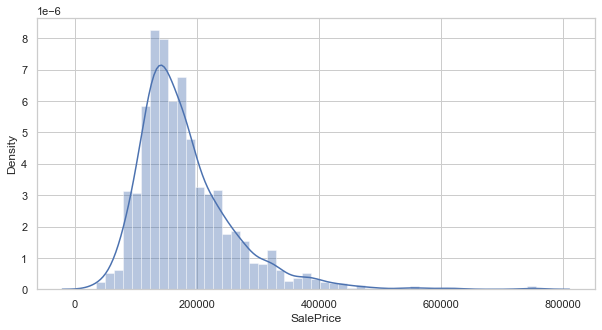

In [974]:
f, ax = plt.subplots(figsize=(10, 5))
sns.distplot(df_train['SalePrice'])

In [975]:
df_train = df_train[df_train['SalePrice'] <= 450000]

In [976]:
# Уникальные значения в качестве и площади бассейна
display(df_train['PoolQC'].unique())
display(df_train['PoolArea'].nunique())
display(df_train['PoolArea'].unique())

array([nan, 'Ex', 'Fa', 'Gd'], dtype=object)

7

array([  0, 512, 648, 576, 480, 519, 738], dtype=int64)

In [977]:
df_train.groupby(by=['PoolQC', 'PoolArea'])['SalePrice'].mean()

PoolQC  PoolArea
Ex      512         235000
Fa      519         250000
        648         181000
Gd      480         160000
        576         171000
        738         274970
Name: SalePrice, dtype: int64

In [978]:
df_train[df_train['PoolArea'] != 0]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000
810,811,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,648,Fa,GdPrv,NaN,0,1,2006,WD,Normal,181000
1170,1171,80,RL,76.0,9880,Pave,NaN,Reg,Lvl,AllPub,...,576,Gd,GdPrv,NaN,0,7,2008,WD,Normal,171000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1386,1387,60,RL,80.0,16692,Pave,NaN,IR1,Lvl,AllPub,...,519,Fa,MnPrv,TenC,2000,7,2006,WD,Normal,250000
1423,1424,80,RL,NaN,19690,Pave,NaN,IR1,Lvl,AllPub,...,738,Gd,GdPrv,NaN,0,8,2006,WD,Alloca,274970


In [979]:
pool_dict = {np.nan: 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}
df_train['PoolQC'] = df_train['PoolQC'].apply(lambda x: pool_dict[x])
df_test['PoolQC'] = df_test['PoolQC'].apply(lambda x: pool_dict[x])

#### Влияние типа продаваемого объекта на его цену

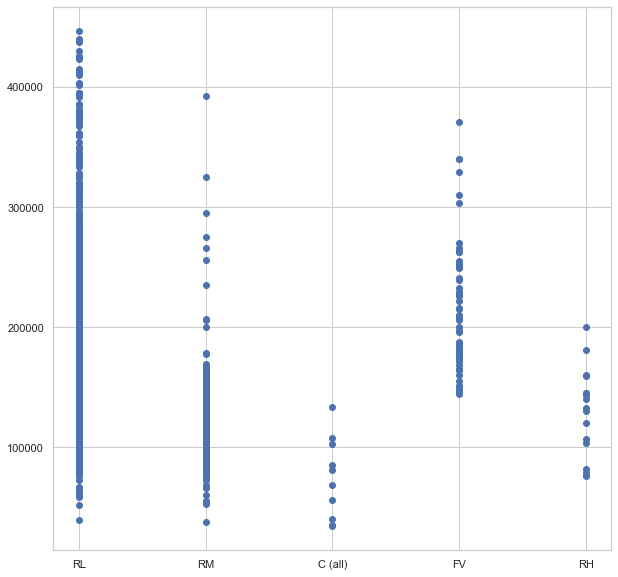

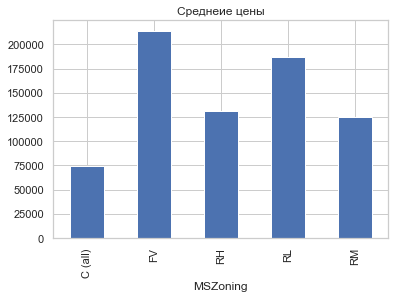

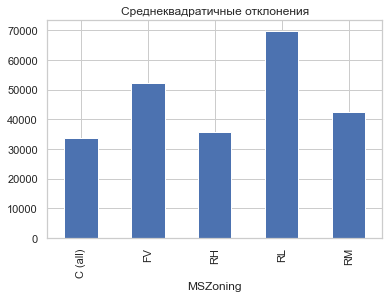

In [980]:
fig, ax = plt.subplots(figsize = (10, 10))
ax.scatter(x = df_train['MSZoning'], y = df_train['SalePrice'])
plt.show()
plt.title('Среднеие цены')
df_train.groupby('MSZoning').SalePrice.mean().plot(kind = 'bar')
plt.show()
plt.title('Среднеквадратичные отклонения')
df_train.groupby('MSZoning').SalePrice.std().plot(kind = 'bar')
plt.show()

In [981]:
zone = {'RL': 4, 'FV': 5, 'RM': 3, 'RH': 3, 'C (all)': 1}
df_train['MSZoning'] = df_train['MSZoning'].apply(lambda x: zone[x])

In [982]:
df_train[df_train.Street == 'Grvl']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
52,53,90,3,110.0,8472,Grvl,NaN,IR2,Bnk,AllPub,...,0,0,NaN,NaN,0,5,2010,WD,Normal,110000
335,336,190,4,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,0,NaN,Shed,700,8,2008,WD,Normal,228950
582,583,90,4,81.0,11841,Grvl,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,0,5,2007,WD,Normal,118500
812,813,20,1,66.0,8712,Grvl,NaN,Reg,Bnk,AllPub,...,0,0,NaN,Shed,54,6,2010,WD,Alloca,55993
1061,1062,30,1,120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,0,NaN,Shed,560,8,2008,ConLD,Normal,81000
1184,1185,20,4,50.0,35133,Grvl,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,0,5,2007,WD,Normal,186700


In [983]:
df_test.Street.value_counts()

Pave    1453
Grvl       6
Name: Street, dtype: int64

#### Признак Utilities фактически содержит только одно значение, а значение целевой переменная находится не так далеко от медианы (между первым и вторым квартилем), поэтому его дропаем

In [984]:
df_train[df_train['Utilities'] != 'AllPub']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
944,945,20,4,NaN,14375,Pave,NaN,IR1,Lvl,NoSeWa,...,0,0,NaN,NaN,0,1,2009,COD,Abnorml,137500


In [985]:
df_test[df_test['Utilities'] != 'AllPub']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
455,1916,30,NaN,109.0,21780,Grvl,NaN,Reg,Lvl,NaN,...,0,0,0,NaN,NaN,0,3,2009,ConLD,Normal
485,1946,20,RL,NaN,31220,Pave,NaN,IR1,Bnk,NaN,...,0,0,0,NaN,Shed,750,5,2008,WD,Normal


#### Центральное кондиционирование повышает среднюю цену в 1.6 раз, поэтому есть смысл оставить этот признак, предварительно переведя его в бинарный

In [986]:
df_train['CentralAir'] = df_train['CentralAir'].apply(lambda x: 1 if x != 'N' else 0)
df_test['CentralAir'] = df_test['CentralAir'].apply(lambda x: 1 if x != 'N' else 0)

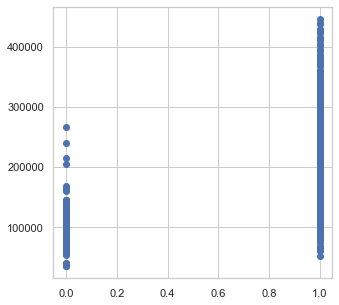

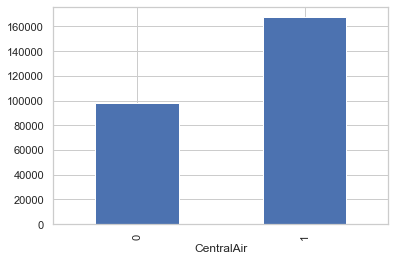

In [987]:
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train['CentralAir'], y = df_train['SalePrice'])
plt.show()
df_train.groupby('CentralAir').SalePrice.median().plot(kind = 'bar')
plt.show()

#### То же проделаем с подъездным покрытием

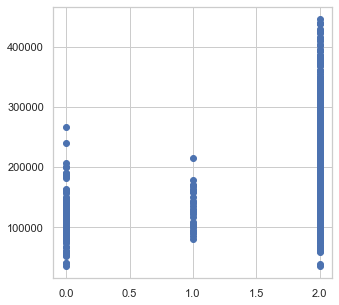

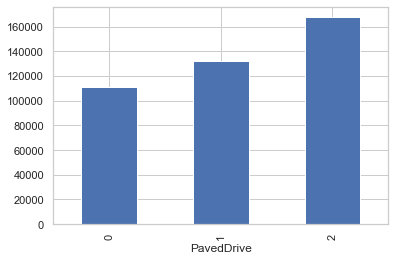

In [988]:
change4 = {'Y': 2, 'P': 1, 'N': 0}
df_train['PavedDrive'] = df_train['PavedDrive'].apply(lambda x: change4[x])
df_test['PavedDrive'] = df_test['PavedDrive'].apply(lambda x: change4[x])

fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train['PavedDrive'], y = df_train['SalePrice'])
plt.show()
df_train.groupby('PavedDrive').SalePrice.median().plot(kind = 'bar')
plt.show()

In [989]:
from scipy.stats import pointbiserialr
pointbiserialr(df_train['PavedDrive'], df_train['SalePrice'])

PointbiserialrResult(correlation=0.24891766673926452, pvalue=7.33517587698987e-22)

#### Наличие и тип забора не сильно влияют на целевую переменную, поэтому удалим этот параметр

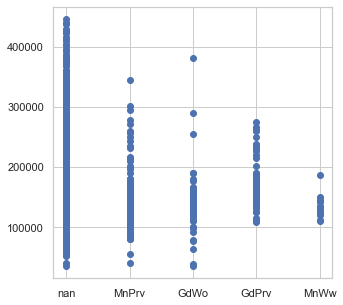

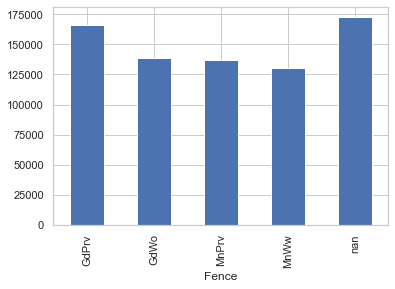

In [990]:
df_train['Fence'] = df_train['Fence'].astype(str)
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train['Fence'], y = df_train['SalePrice'])
plt.show()
df_train.groupby('Fence').SalePrice.median().plot(kind = 'bar')
plt.show()

#### Выбросим пропущенные значения в некоторых строках

In [991]:
df_train = df_train[df_train['Electrical'].notna()]
# df_train = df_train[df_train['MasVnrArea'].notna()]

In [992]:
from scipy.stats import pearsonr
pearsonr(df_train[df_train['MasVnrArea'].notna()]['MasVnrArea'],
        df_train[df_train['MasVnrArea'].notna()]['SalePrice'])

(0.4313760609855165, 3.039222325232951e-66)

#### Электросеть

In [993]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1445 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1445 non-null   int64  
 1   MSSubClass     1445 non-null   int64  
 2   MSZoning       1445 non-null   int64  
 3   LotFrontage    1187 non-null   float64
 4   LotArea        1445 non-null   int64  
 5   Street         1445 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1445 non-null   object 
 8   LandContour    1445 non-null   object 
 9   Utilities      1445 non-null   object 
 10  LotConfig      1445 non-null   object 
 11  LandSlope      1445 non-null   object 
 12  Neighborhood   1445 non-null   object 
 13  Condition1     1445 non-null   object 
 14  Condition2     1445 non-null   object 
 15  BldgType       1445 non-null   object 
 16  HouseStyle     1445 non-null   object 
 17  OverallQual    1445 non-null   int64  
 18  OverallC

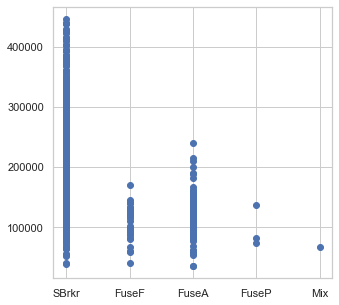

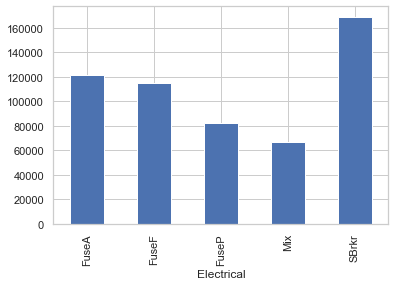

In [994]:
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train['Electrical'], y = df_train['SalePrice'])
plt.show()
df_train.groupby('Electrical').SalePrice.median().plot(kind = 'bar')
plt.show()

In [995]:
electric = {'SBrkr': 5, 'FuseA': 4, 'FuseF': 3, 'FuseP': 2, 'Mix': 1}
df_train['Electrical'] = df_train['Electrical'].apply(lambda x: electric[x])
df_test['Electrical'] = df_test['Electrical'].apply(lambda x: electric[x])

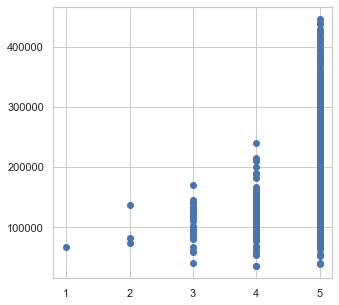

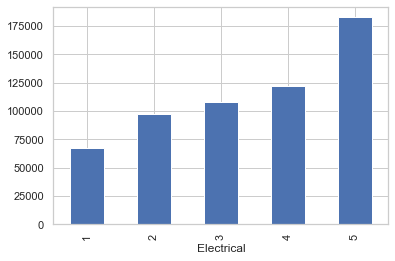

In [996]:
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train['Electrical'], y = df_train['SalePrice'])
plt.show()
df_train.groupby('Electrical').SalePrice.mean().plot(kind = 'bar')
plt.show()

#### Отопление

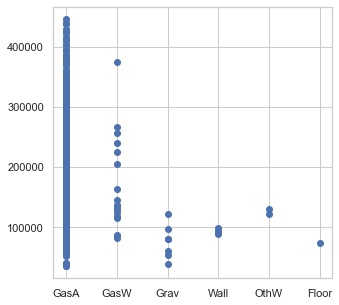

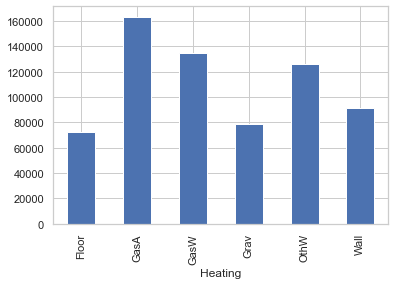

In [997]:
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train['Heating'], y = df_train['SalePrice'])
plt.show()
df_train.groupby('Heating').SalePrice.median().plot(kind = 'bar')
plt.show()

In [998]:
# heat = {'GasA': 3, 'GasW': 2, 'OthW': 2, 'Grav': 1, 'Wall': 1, 'Floor': 1} 

In [999]:
df_train = df_train[(df_train['SalePrice'] < 700000)]
df_train['Heating'] = df_train['Heating'].astype("category")
df_test['Heating'] = df_test['Heating'].astype("category")

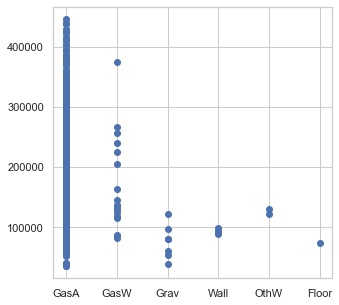

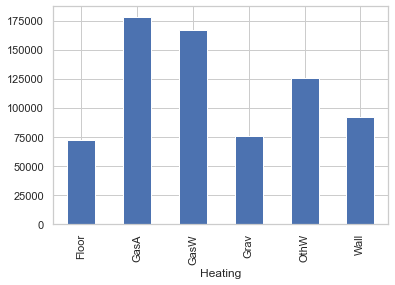

In [1000]:
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train['Heating'], y = df_train['SalePrice'])
plt.show()
df_train.groupby('Heating').SalePrice.mean().plot(kind = 'bar')
plt.show()

#### Фундамент

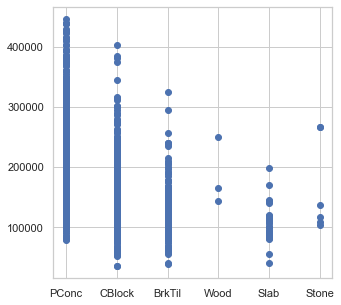

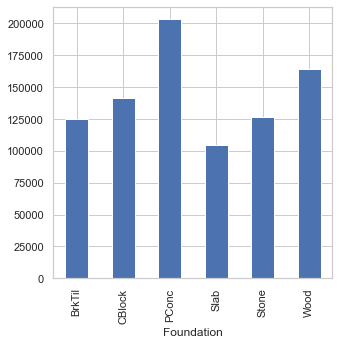

In [1001]:
s = 'Foundation'
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()
plt.figure(figsize = (5, 5))
df_train.sort_values(by=s).groupby(s).SalePrice.median().plot(kind = 'bar')
plt.show()

In [1002]:
df_train['Foundation'] = df_train['Foundation'].astype("category")
df_test['Foundation'] = df_test['Foundation'].astype("category")

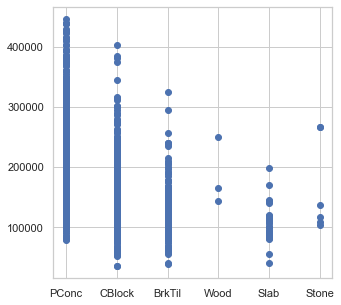

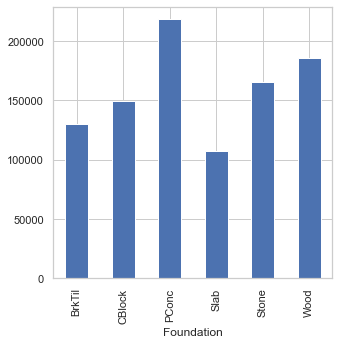

In [1003]:
s = 'Foundation'
fig, ax = plt.subplots(figsize = (5, 5))
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()
plt.figure(figsize = (5, 5))
df_train.sort_values(by=s).groupby(s).SalePrice.mean().plot(kind = 'bar')
plt.show()

#### В параметре MiscFeature выделяется только теннисный корт, но в выборке он всего один. Не очень то репрезентативно, поэтому удалим признак

#### MiscVal почти не коррелирует, ведет себя очень странно, имеет довольно большое p-значение, поэтому дропнем его

In [1004]:
df_train[df_train['MiscVal'] > 0][['MiscVal', 'MiscFeature', 'SalePrice']]

,MiscVal,MiscFeature,SalePrice
5,700,Shed,143000
7,350,Shed,200000
16,700,Shed,149000
17,500,Shed,90000
51,400,Shed,114500
84,700,Shed,168500
95,480,Shed,185000
98,400,Shed,83000
99,400,Shed,128950
106,450,Shed,100000


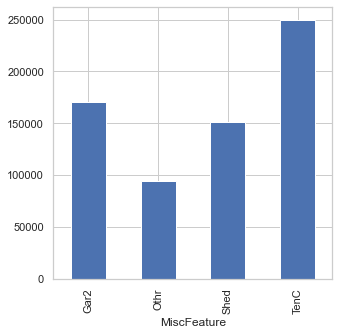

In [1005]:
s = 'MiscFeature'
plt.figure(figsize = (5, 5))
df_train.sort_values(by=s).groupby(s).SalePrice.mean().plot(kind = 'bar')
plt.show()

In [1006]:
display(pearsonr(df_train.MiscVal, df_train.SalePrice))

(-0.019588492850101443, 0.4568477863841579)

#### От месяца продажи, а особенно от года, целевая переменная не меняется вообще, поэтому удалим их

In [1007]:
# df_train.drop(columns = ['YrSold', 'MoSold'], inplace = True)
# df_test.drop(columns = ['YrSold', 'MoSold'], inplace = True)

#### LotFrontage имеет много пропущенных значений (~20%), а коррелирует с целевой переменной не так уж сильно (заполнение медианой не повысило зависимость), поэтому его стоит дропнуть

In [1008]:
# df_train.drop(columns = ['LotFrontage'], inplace = True)
# df_test.drop(columns = ['LotFrontage'], inplace = True)

#### В типе гаража и дате его постройки есть пропущенные значения, которые понизят точность при предсказании на тестовом датасете. Плюсом эти столбцы зависимы с некоторыми другими. Поэтому дропнем их

In [1009]:
# df_train.drop(columns = ['GarageType', 'GarageYrBlt'], inplace = True)
# df_test.drop(columns = ['GarageType', 'GarageYrBlt'], inplace = True)

#### В большинстве квартир всего 1 кухня, а кол-во спален не влияет на цену

#### Многие категориальные перизнаки - рейтинги, поэтому заменим их числами в иерархическом порядке

In [1010]:
change1_rating = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, np.nan: 0, 'nan': 0}
change2_rating = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'nan': 0}
change3_rating = {'Fin': 4, 'RFn': 3, 'Unf': 1, 'nan': 0}
change4_rating = {'SBrkr': 5, 'FuseA': 4, 'FuseF': 3, 'FuseP': 2, 'Mix': 1}

In [1011]:
df_train['BsmtExposure'] = df_train['BsmtExposure'].astype("category")
df_train['GarageFinish'] = df_train['GarageFinish'].astype("category")
df_train['GarageQual'] = df_train['GarageQual'].astype("category")
df_train['GarageCond'] = df_train['GarageCond'].astype("category")
df_train['BsmtExposure'] = df_train['BsmtExposure'].apply(lambda x: change2_rating[x])
df_train['ExterQual'] = df_train['ExterQual'].apply(lambda x: change1_rating[x])
df_train['ExterCond'] = df_train['ExterCond'].apply(lambda x: change1_rating[x])
df_train['GarageQual'] = df_train['GarageQual'].apply(lambda x: change1_rating[x])
df_train['GarageCond'] = df_train['GarageCond'].apply(lambda x: change1_rating[x])
df_train['BsmtCond'] = df_train['BsmtCond'].apply(lambda x: change1_rating[x])
df_train['BsmtQual'] = df_train['BsmtQual'].apply(lambda x: change1_rating[x])
df_train['HeatingQC'] = df_train['HeatingQC'].apply(lambda x: change1_rating[x])
df_train['KitchenQual'] = df_train['KitchenQual'].apply(lambda x: change1_rating[x])
df_train['FireplaceQu'] = df_train['FireplaceQu'].apply(lambda x: change1_rating[x])
df_train['GarageFinish'] = df_train['GarageFinish'].apply(lambda x: change3_rating[x])

In [1012]:
df_test['BsmtExposure'] = df_test['BsmtExposure'].astype("category")
df_test['GarageFinish'] = df_test['GarageFinish'].astype("category")
df_test['GarageQual'] = df_test['GarageQual'].astype("category")
df_test['GarageCond'] = df_test['GarageCond'].astype("category")
df_test['BsmtExposure'] = df_test['BsmtExposure'].apply(lambda x: change2_rating[x])
df_test['ExterQual'] = df_test['ExterQual'].apply(lambda x: change1_rating[x])
df_test['ExterCond'] = df_test['ExterCond'].apply(lambda x: change1_rating[x])
df_test['GarageQual'] = df_test['GarageQual'].apply(lambda x: change1_rating[x])
df_test['GarageCond'] = df_test['GarageCond'].apply(lambda x: change1_rating[x])
df_test['BsmtCond'] = df_test['BsmtCond'].apply(lambda x: change1_rating[x])
df_test['BsmtQual'] = df_test['BsmtQual'].apply(lambda x: change1_rating[x])
df_test['HeatingQC'] = df_test['HeatingQC'].apply(lambda x: change1_rating[x])
df_test['KitchenQual'] = df_test['KitchenQual'].apply(lambda x: change1_rating[x])
df_test['FireplaceQu'] = df_test['FireplaceQu'].apply(lambda x: change1_rating[x])
df_test['GarageFinish'] = df_test['GarageFinish'].apply(lambda x: change3_rating[x])

#### Восстановим индексы, которые изменились после удалений строк

In [1013]:
df_train = df_train.reset_index(drop = True)

In [1014]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1445 non-null   int64   
 1   MSSubClass     1445 non-null   int64   
 2   MSZoning       1445 non-null   int64   
 3   LotFrontage    1187 non-null   float64 
 4   LotArea        1445 non-null   int64   
 5   Street         1445 non-null   object  
 6   Alley          91 non-null     object  
 7   LotShape       1445 non-null   object  
 8   LandContour    1445 non-null   object  
 9   Utilities      1445 non-null   object  
 10  LotConfig      1445 non-null   object  
 11  LandSlope      1445 non-null   object  
 12  Neighborhood   1445 non-null   object  
 13  Condition1     1445 non-null   object  
 14  Condition2     1445 non-null   object  
 15  BldgType       1445 non-null   object  
 16  HouseStyle     1445 non-null   object  
 17  OverallQual    1445 non-null   in

In [1015]:
df_train.Alley.fillna("Not", inplace=True)
df_test.Alley.fillna("Not", inplace=True)
df_train.MiscFeature.fillna("Not", inplace=True)
df_test.MiscFeature.fillna("Not", inplace=True)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1445 non-null   int64   
 1   MSSubClass     1445 non-null   int64   
 2   MSZoning       1445 non-null   int64   
 3   LotFrontage    1187 non-null   float64 
 4   LotArea        1445 non-null   int64   
 5   Street         1445 non-null   object  
 6   Alley          1445 non-null   object  
 7   LotShape       1445 non-null   object  
 8   LandContour    1445 non-null   object  
 9   Utilities      1445 non-null   object  
 10  LotConfig      1445 non-null   object  
 11  LandSlope      1445 non-null   object  
 12  Neighborhood   1445 non-null   object  
 13  Condition1     1445 non-null   object  
 14  Condition2     1445 non-null   object  
 15  BldgType       1445 non-null   object  
 16  HouseStyle     1445 non-null   object  
 17  OverallQual    1445 non-null   in

## Шаг 2
## Визуализируем, ищем выбросы

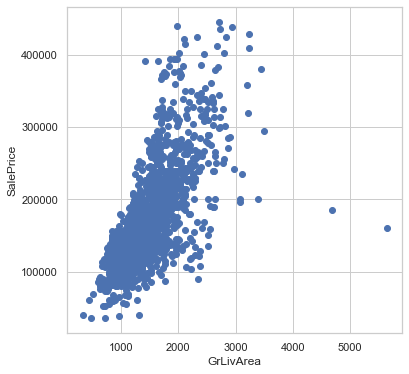

In [1016]:
s = 'GrLivArea'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1017]:
df_train = df_train[df_train[s] < 4000]

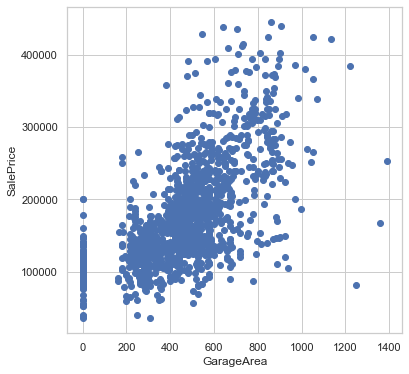

In [1018]:
s = 'GarageArea'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1019]:
df_train = df_train[(df_train[s] < 1200) | (df_train['SalePrice'] > 300000)]

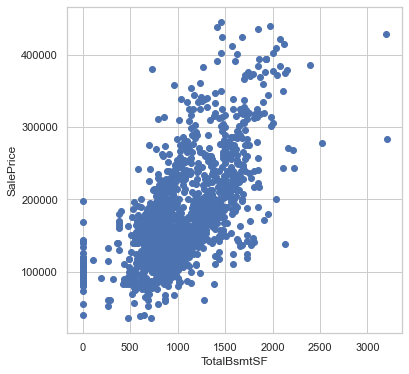

In [1020]:
s = 'TotalBsmtSF'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1021]:
df_train = df_train[df_train[s] < 2500]

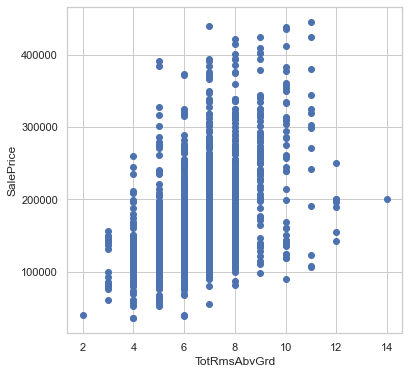

In [1022]:
s = 'TotRmsAbvGrd'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1023]:
df_train = df_train[(df_train[s] < 14)]
df_train = df_train[(df_train[s] != 5) | (df_train['SalePrice'] < 350000)]

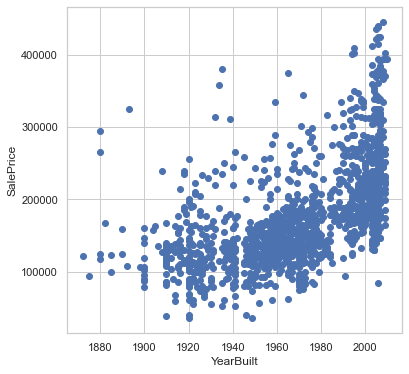

In [1024]:
s = 'YearBuilt'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1025]:
df_train = df_train[(df_train[s] < 1983) | (df_train['SalePrice'] > 100000)]
df_train = df_train[(df_train[s] > 1900) | (df_train['SalePrice'] < 250000)]
df_train = df_train[(df_train[s] > 1978) | (df_train['SalePrice'] < 310000)]

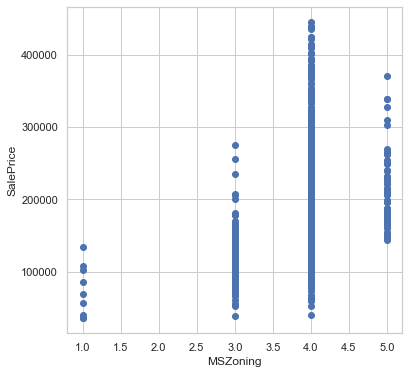

In [1026]:
s = 'MSZoning'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1027]:
df_train = df_train[(df_train[s] != 3) | (df_train['SalePrice'] < 250000)]
df_train = df_train[(df_train[s] != 5) | (df_train['SalePrice'] < 320000)]

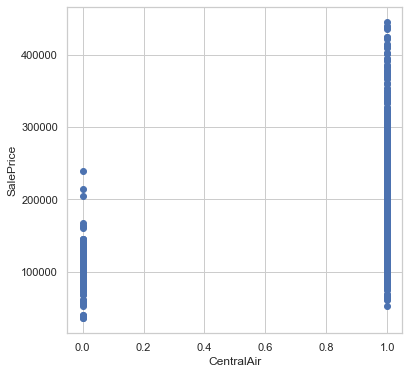

In [1028]:
s = 'CentralAir'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1029]:
df_train = df_train[(df_train[s] != 0) | (df_train['SalePrice'] < 200000)]

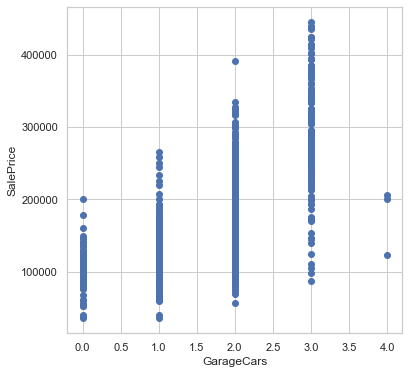

In [1030]:
s = 'GarageCars'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()

In [1031]:
df_train = df_train[(df_train[s] != 0) | (df_train['SalePrice'] < 190000)]
df_train = df_train[(df_train[s] != 2) | (df_train['SalePrice'] < 350000)]
df_train[s] = df_train[s].apply(lambda x: 4 if x == 3 else x)
df_test[s] = df_test[s].apply(lambda x: 4 if x == 3 else x)

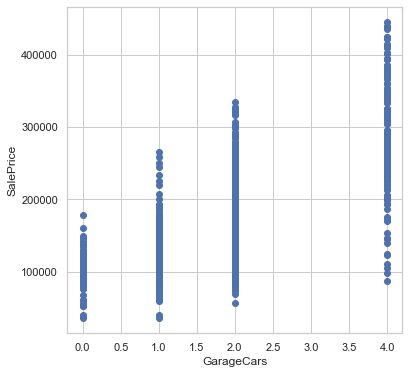

In [1032]:
s = 'GarageCars'
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlabel(s)
ax.set_ylabel('SalePrice')
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()
df_train.drop(columns = ['GarageArea'], inplace = True)

In [1033]:
df_train[quals].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1411 entries, 0 to 1444
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   SalePrice    1411 non-null   int64
 1   ExterQual    1411 non-null   int64
 2   ExterCond    1411 non-null   int64
 3   BsmtCond     1411 non-null   int64
 4   BsmtQual     1411 non-null   int64
 5   HeatingQC    1411 non-null   int64
 6   KitchenQual  1411 non-null   int64
 7   FireplaceQu  1411 non-null   int64
 8   OverallQual  1411 non-null   int64
 9   OverallCond  1411 non-null   int64
dtypes: int64(10)
memory usage: 121.3 KB


## Шаг 3
## Создаем фичи

#### У нас очень много рейтингов, которые коррелируют с целевой переменной по-разному, почему бы не попробовать их объеденить?

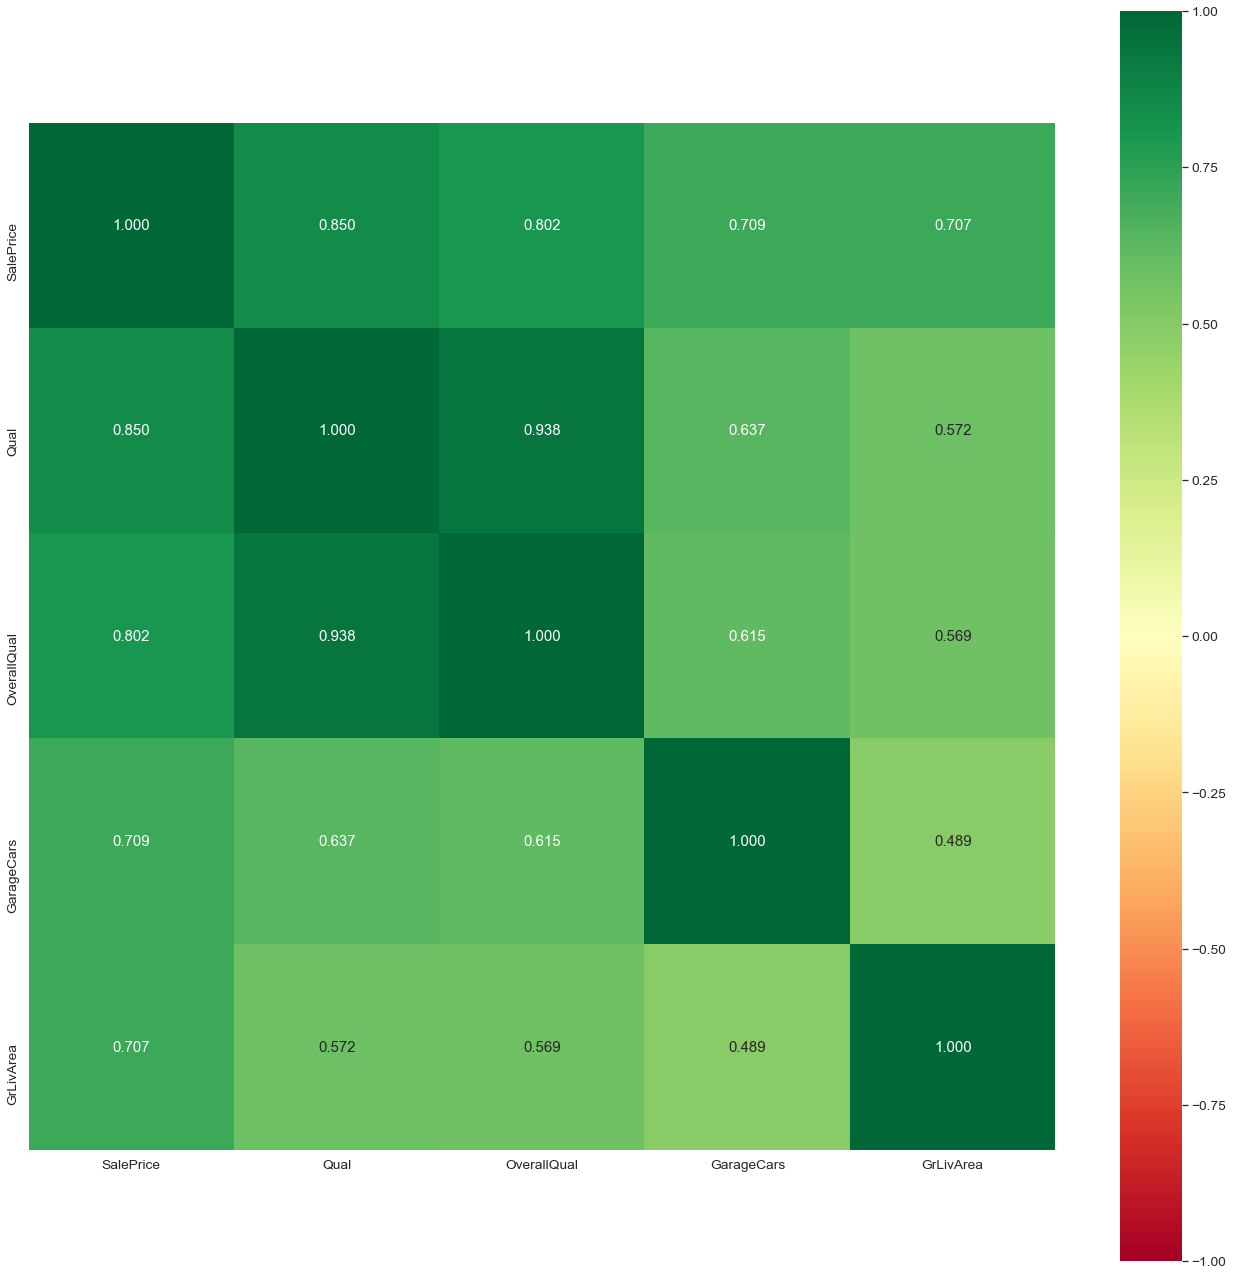

In [1034]:
quals = [
         'SalePrice',
         #'BsmtExposure',
         'ExterQual',
         'ExterCond',
         'BsmtCond',
         'BsmtQual',
         'HeatingQC',
         'KitchenQual',
         'FireplaceQu',
         'OverallQual',
         'OverallCond'
        ]
quals_dict = {'SalePrice': 1, 'BsmtExposure': 1, 'ExterQual': 2, 'ExterCond': 1, 'GarageQual': 1,
              'GarageCond': 1, 'BsmtCond': 1, 'BsmtQual': 1, 'HeatingQC': 1, 'KitchenQual': 2,
              'FireplaceQu': 1, 'GarageFinish': 1, 'OverallQual': 2, 'OverallCond': 1}
df_train['Qual'] = 0
df_test['Qual'] = 0
cm = np.corrcoef(df_train[quals].values.T)[0]
for i in range(1, len(quals)):
    df_train['Qual'] += df_train[quals[i]]*quals_dict[quals[i]]*int(abs(cm[i]*10))
    df_test['Qual'] += df_test[quals[i]]*quals_dict[quals[i]]*int(abs(cm[i]*10))

k = 5
corrmat = df_train.corr()
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
sns.set(font_scale=1.25)
plt.figure(figsize = (23, 23))
hm = sns.heatmap(cm, cbar=True, annot=True, square=True,
                fmt='.3f', annot_kws={'size': 15}, cmap='RdYlGn',
                center=0, vmax=1, vmin=-1,
                yticklabels=cols.values, xticklabels=cols.values)

#### Получился отличный параметр, который кореллирует с целевой переменной больше, чем каждая его составляющая

In [1035]:
# df_train.drop(columns = quals[1:], inplace = True)
# df_test.drop(columns = quals[1:], inplace = True)

#### Также стоит попробовать сформировать параметр, который отвечает за оснащение дома: печи, электричество, газ, гаражи и т.п.

###### перебирая коэффиценты в словаре, можно добиться более сильной корреляции нового параметра с целевым, но нужно следить, чтобы корреляция с Qual была не очень сильная (буду пробовать повышать коэффиценты тех параметров Equipment, которые не сильно зависят от Qual)

In [1036]:
df_test['GarageCars'].fillna(df_test['GarageCars'].median(), inplace = True)

In [1037]:
df_test[equip].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fireplaces  1459 non-null   int64  
 1   CentralAir  1459 non-null   int64  
 2   GarageCars  1459 non-null   float64
 3   PavedDrive  1459 non-null   int64  
 4   PoolArea    1459 non-null   int64  
 5   Electrical  1459 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 68.5 KB


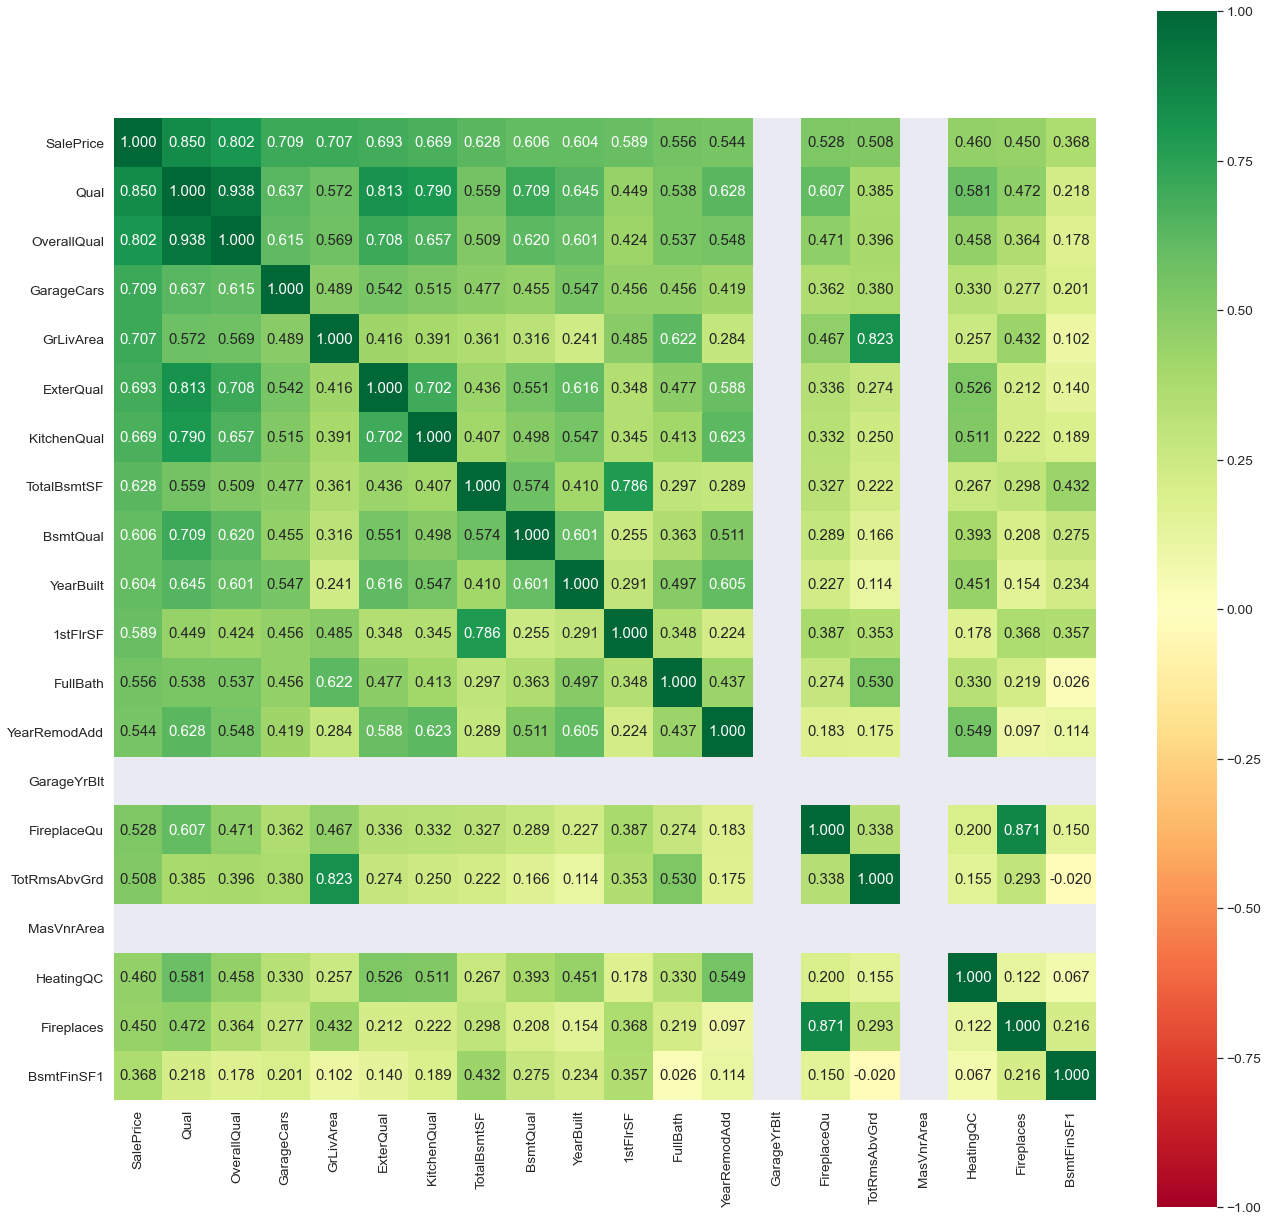

In [1038]:
equip = ['Fireplaces', 'CentralAir', 'GarageCars', 'PavedDrive', 'PoolArea',
         'Electrical']
equip_dict = {'Fireplaces': 0.6, 'CentralAir': 1, 'GarageCars': 1, 'PavedDrive': 1, 'Heating': 1,
              'Foundation': 0.1, 'PoolArea': 10, 'Electrical': 1}
df_train['Equipment'] = 0
df_test['Equipment'] = 0
cm = np.corrcoef(df_train[equip].values.T)[0]
for i in range(0, len(equip)):
    df_train['Equipment'] += df_train[equip[i]]*equip_dict[equip[i]]*int(abs(cm[i]*100))
    df_test['Equipment'] += df_test[equip[i]]*equip_dict[equip[i]]*int(abs(cm[i]*100))

k = 20
corrmat = df_train.corr()
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
sns.set(font_scale=1.25)
plt.figure(figsize = (22, 22))
hm = sns.heatmap(cm, cbar=True, annot=True, square=True,
                fmt='.3f', annot_kws={'size': 15}, cmap='RdYlGn',
                center=0, vmax=1, vmin=-1,
                yticklabels=cols.values, xticklabels=cols.values)

In [1039]:
# df_train.drop(columns = equip, inplace = True)
# df_test.drop(columns = equip, inplace = True)

###### Эта фича сильно коррелирует с целевой переменной, но и с Qual, поэтому по ней можно попробовать тренировать, но нужно быть готовым к тому, что она не поможет

In [1040]:
from sklearn import preprocessing
p = preprocessing.normalize([df_train.SalePrice])
p[0].min()

0.004957498405630975

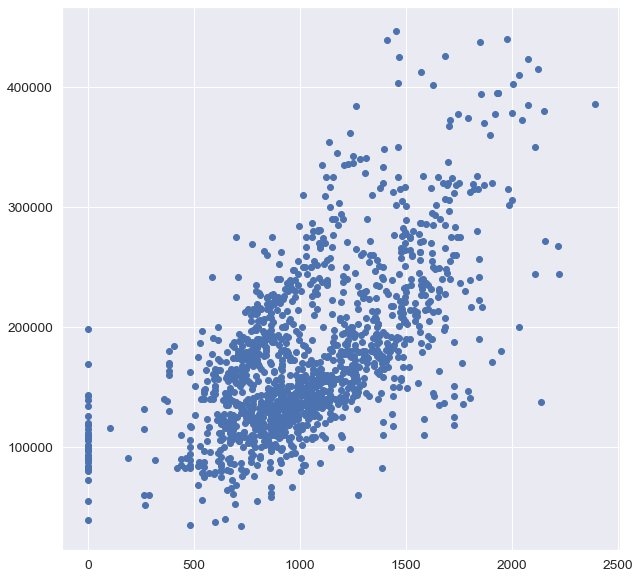

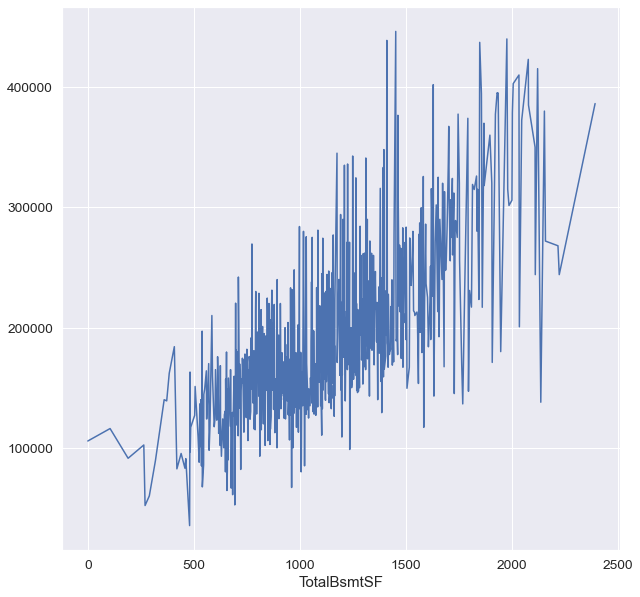

In [1041]:
s = 'TotalBsmtSF'
fig, ax = plt.subplots(figsize = (10, 10))
ax.scatter(x = df_train[s], y = df_train['SalePrice'])
plt.show()
plt.figure(figsize = (10, 10))
df_train.sort_values(by=s).groupby(s).SalePrice.mean().plot(kind = 'line')
plt.show()

In [1042]:
df_train = df_train[df_train['GarageType'].notna()]
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1334 entries, 0 to 1444
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1334 non-null   int64   
 1   MSSubClass     1334 non-null   int64   
 2   MSZoning       1334 non-null   int64   
 3   LotFrontage    1088 non-null   float64 
 4   LotArea        1334 non-null   int64   
 5   Street         1334 non-null   object  
 6   Alley          1334 non-null   object  
 7   LotShape       1334 non-null   object  
 8   LandContour    1334 non-null   object  
 9   Utilities      1334 non-null   object  
 10  LotConfig      1334 non-null   object  
 11  LandSlope      1334 non-null   object  
 12  Neighborhood   1334 non-null   object  
 13  Condition1     1334 non-null   object  
 14  Condition2     1334 non-null   object  
 15  BldgType       1334 non-null   object  
 16  HouseStyle     1334 non-null   object  
 17  OverallQual    1334 non-null   in

<AxesSubplot:>

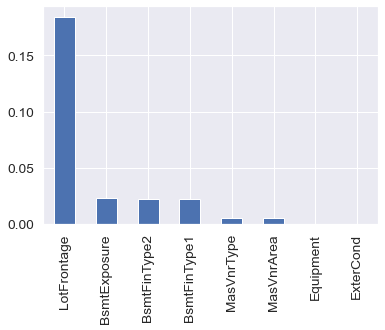

In [1043]:
total = df_test.isnull().sum().sort_values(ascending = False)
percent = (df_train.isnull().sum() / df_train.isnull().count()).sort_values(ascending = False)
percent_data = percent.head(8)
percent_data.plot(kind = 'bar')

<AxesSubplot:xlabel='TotalBsmtSF', ylabel='Density'>

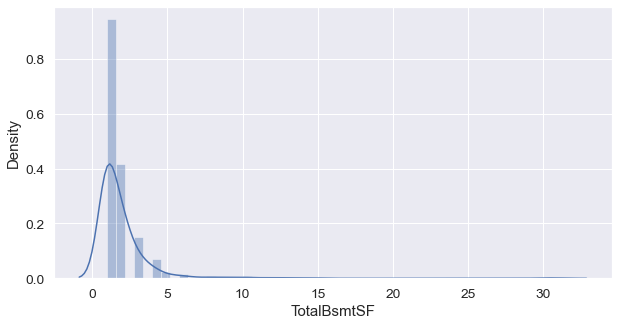

In [1044]:
f, ax = plt.subplots(figsize=(10, 5))
sns.distplot(df_train['TotalBsmtSF'].value_counts())

In [1045]:
df_train['TotalBsmtSF'].fillna(df_train['TotalBsmtSF'].mean(), inplace = True)
df_train['MSZoning'].fillna('RM', inplace = True)
df_train['BsmtFullBath'].fillna(df_train['BsmtFullBath'].mean(), inplace = True)
df_train['LotFrontage'].fillna(df_train['LotFrontage'].median(), inplace = True)

In [1046]:
df_test['TotalBsmtSF'].fillna(df_test['TotalBsmtSF'].mean(), inplace = True)
df_test['MSZoning'].fillna('RM', inplace = True)
df_test['BsmtFullBath'].fillna(df_test['BsmtFullBath'].mean(), inplace = True)
df_test['LotFrontage'].fillna(df_test['LotFrontage'].mean(), inplace = True)

In [1047]:
numerical_features = [i for i in df_train.columns if df_train[i].dtypes != 'O']
categorial_features = [i for i in df_train.columns if df_train[i].dtypes == 'O']
train_features_with_na = [i for i in df_train if df_train[i].isna().sum()]
test_features_with_na = [i for i in df_test if df_test[i].isna().sum()]
for element in categorial_features: 
    df_train[element]= df_train[element].astype('category')
train_features_with_na

['MasVnrType', 'MasVnrArea', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

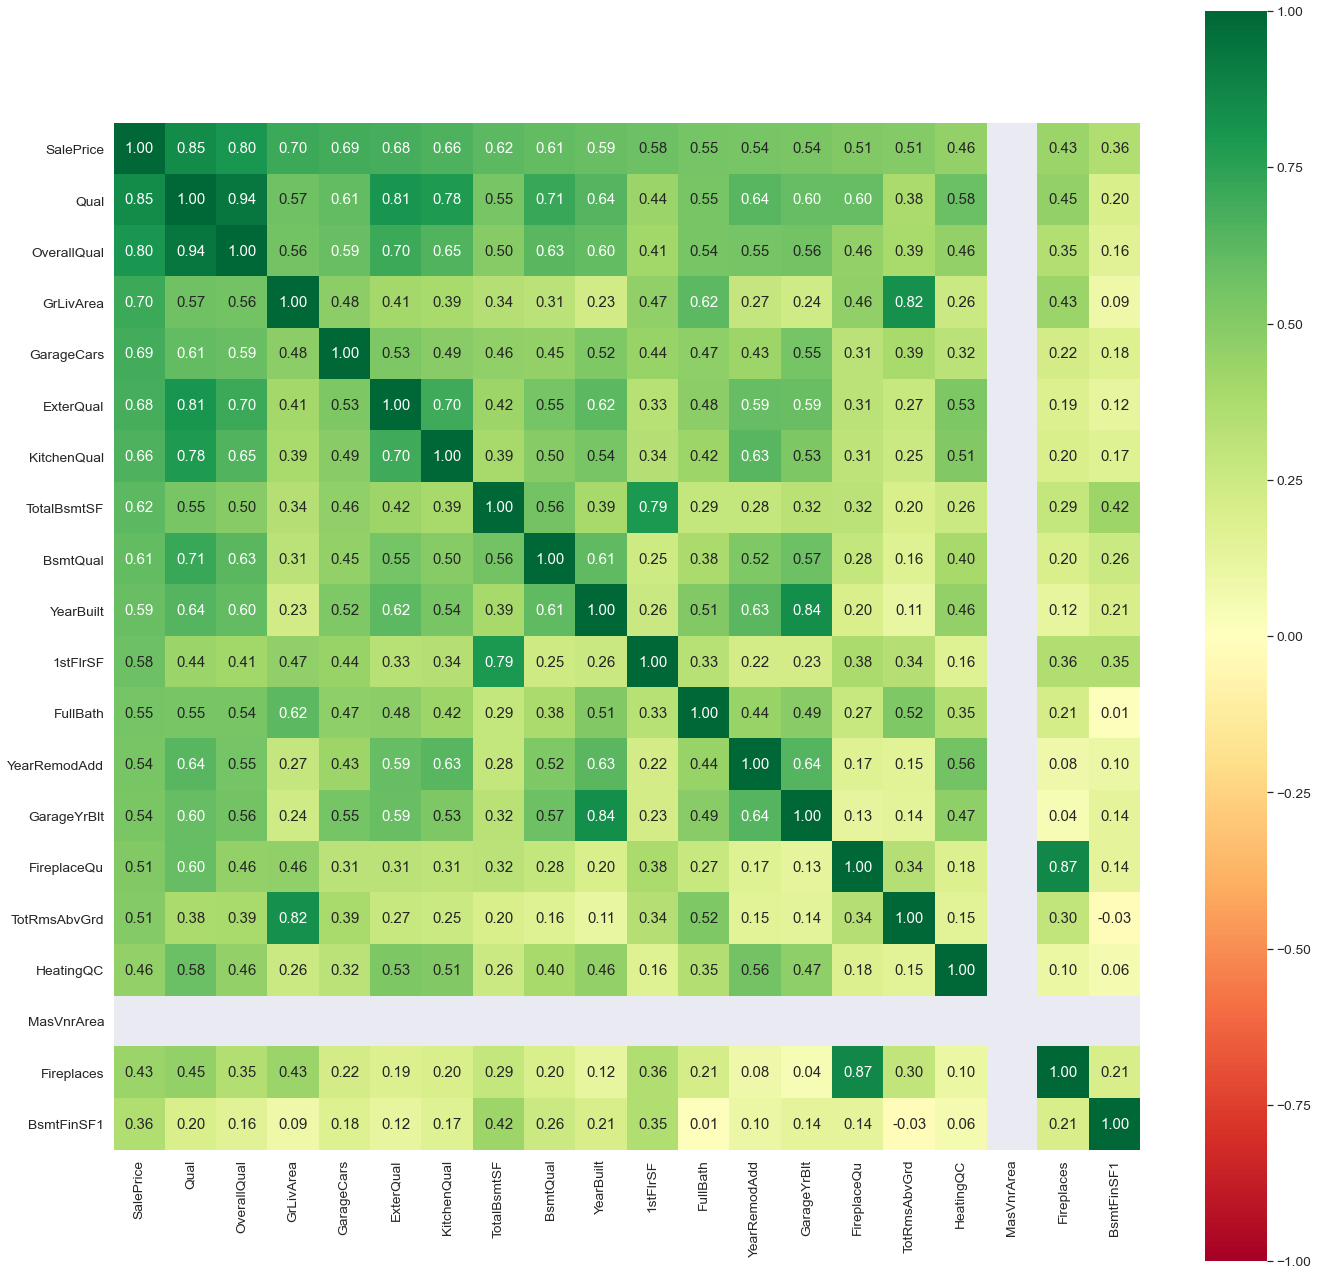

In [1048]:
k = 20
corrmat = df_train.corr()
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
sns.set(font_scale=1.25)
plt.figure(figsize = (23, 23))
hm = sns.heatmap(cm, cbar=True, annot=True, square=True,
                fmt='.2f', annot_kws={'size': 15}, cmap='RdYlGn',
                center=0, vmax=1, vmin=-1,
                yticklabels=cols.values, xticklabels=cols.values)

In [1052]:
y = df_train['SalePrice']
# features = ['OverallQual',
#             'GarageCars', 
#             'GrLivArea',
#             'TotalBsmtSF',
#             'ExterQual', 
#             'KitchenQual', 
#             'Neighborhood',
#             'LotShape',
#             'LandContour',
#             'SaleType']

features = [
            'Qual',
            'GarageCars', 
            'GrLivArea',
            'TotalBsmtSF', 
            'Neighborhood',
            'LotShape',
            'LandContour',
            'SaleType',
            'YearBuilt'
           ]

df_test = df_test[features]
df_test.GarageCars.fillna(df_test.GarageCars.median(), inplace=True)
df_test.SaleType.fillna('Con', inplace=True)
df_test.info()

X = pd.get_dummies(df_train[features]) 
test_X = pd.get_dummies(df_test[features])
train_x, val_x, train_y, val_y = train_test_split(X, y, test_size = 0.3)


las_model = Lasso(alpha=60)
las_model.fit(X, y)
pred_y2 = las_model.predict(test_X)
# las_model.fit(train_x, train_y)
# pred_y2 = las_model.predict(val_x)

cat_model = CatBoostRegressor(iterations=9999)
cat_model.fit(X, y)
pred_y5 = cat_model.predict(test_X)
# cat_model.fit(train_x, train_y)
# pred_y5 = cat_model.predict(val_x)

xgb_model = XGBRegressor()
xgb_model.fit(X, y)
pred_y6 = xgb_model.predict(test_X)
# xgb_model.fit(train_x, train_y)
# pred_y6 = xgb_model.predict(val_x)

pred_y = (pred_y2 + 2*pred_y5 + pred_y6) / 4
# print(f'Lasso: {np.sqrt(mean_squared_error(val_y, pred_y2, squared=False))}')
# print(f'Cat: {np.sqrt(mean_squared_error(val_y, pred_y5, squared=False))}')
# print(f'XGB: {np.sqrt(mean_squared_error(val_y, pred_y6, squared=False))}')
# print(f'Ansamb: {np.sqrt(mean_squared_error(val_y, pred_y, squared=False))}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Qual          1459 non-null   int64  
 1   GarageCars    1459 non-null   float64
 2   GrLivArea     1459 non-null   int64  
 3   TotalBsmtSF   1459 non-null   float64
 4   Neighborhood  1459 non-null   object 
 5   LotShape      1459 non-null   object 
 6   LandContour   1459 non-null   object 
 7   SaleType      1459 non-null   object 
 8   YearBuilt     1459 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.7+ KB
Learning rate set to 0.006592
0:	learn: 66298.2188975	total: 2.72ms	remaining: 27.2s
1:	learn: 65976.6232572	total: 4.29ms	remaining: 21.5s
2:	learn: 65671.9808991	total: 6.46ms	remaining: 21.5s
3:	learn: 65354.5454462	total: 8.66ms	remaining: 21.6s
4:	learn: 65031.2102990	total: 10.2ms	remaining: 20.5s
5:	learn: 64733.4932535	total: 11.5ms	remaining: 19.

177:	learn: 33808.2790870	total: 268ms	remaining: 14.8s
178:	learn: 33717.3922945	total: 269ms	remaining: 14.8s
179:	learn: 33628.2549665	total: 271ms	remaining: 14.8s
180:	learn: 33535.2072978	total: 272ms	remaining: 14.8s
181:	learn: 33445.5957338	total: 274ms	remaining: 14.8s
182:	learn: 33360.2485578	total: 276ms	remaining: 14.8s
183:	learn: 33264.7255094	total: 278ms	remaining: 14.8s
184:	learn: 33182.3756867	total: 280ms	remaining: 14.8s
185:	learn: 33100.7444694	total: 281ms	remaining: 14.8s
186:	learn: 33002.5887476	total: 283ms	remaining: 14.8s
187:	learn: 32920.2445225	total: 284ms	remaining: 14.8s
188:	learn: 32836.1790135	total: 286ms	remaining: 14.8s
189:	learn: 32754.5738418	total: 288ms	remaining: 14.9s
190:	learn: 32669.5712231	total: 290ms	remaining: 14.9s
191:	learn: 32585.7960801	total: 292ms	remaining: 14.9s
192:	learn: 32493.8568533	total: 294ms	remaining: 14.9s
193:	learn: 32415.8502727	total: 295ms	remaining: 14.9s
194:	learn: 32325.2070369	total: 297ms	remaining

393:	learn: 23510.5653622	total: 581ms	remaining: 14.2s
394:	learn: 23490.6393978	total: 582ms	remaining: 14.2s
395:	learn: 23466.7214716	total: 583ms	remaining: 14.1s
396:	learn: 23443.6273040	total: 585ms	remaining: 14.2s
397:	learn: 23425.0879296	total: 587ms	remaining: 14.2s
398:	learn: 23403.4435778	total: 589ms	remaining: 14.2s
399:	learn: 23386.6460949	total: 590ms	remaining: 14.2s
400:	learn: 23367.7109957	total: 592ms	remaining: 14.2s
401:	learn: 23348.4252527	total: 593ms	remaining: 14.2s
402:	learn: 23326.2921780	total: 595ms	remaining: 14.2s
403:	learn: 23306.9188089	total: 597ms	remaining: 14.2s
404:	learn: 23288.0199905	total: 599ms	remaining: 14.2s
405:	learn: 23266.7423957	total: 601ms	remaining: 14.2s
406:	learn: 23248.4679489	total: 602ms	remaining: 14.2s
407:	learn: 23227.4694569	total: 604ms	remaining: 14.2s
408:	learn: 23207.4279607	total: 605ms	remaining: 14.2s
409:	learn: 23191.5685103	total: 606ms	remaining: 14.2s
410:	learn: 23172.5787898	total: 607ms	remaining

588:	learn: 21056.3493254	total: 900ms	remaining: 14.4s
589:	learn: 21050.6740976	total: 902ms	remaining: 14.4s
590:	learn: 21042.1561217	total: 908ms	remaining: 14.5s
591:	learn: 21034.2889125	total: 912ms	remaining: 14.5s
592:	learn: 21028.4950333	total: 915ms	remaining: 14.5s
593:	learn: 21017.5173473	total: 920ms	remaining: 14.6s
594:	learn: 21010.7002164	total: 925ms	remaining: 14.6s
595:	learn: 21003.0678037	total: 937ms	remaining: 14.8s
596:	learn: 20992.7846282	total: 946ms	remaining: 14.9s
597:	learn: 20984.8932814	total: 958ms	remaining: 15.1s
598:	learn: 20976.0430490	total: 963ms	remaining: 15.1s
599:	learn: 20969.3812450	total: 966ms	remaining: 15.1s
600:	learn: 20963.1355354	total: 971ms	remaining: 15.2s
601:	learn: 20954.6418932	total: 973ms	remaining: 15.2s
602:	learn: 20945.5246060	total: 975ms	remaining: 15.2s
603:	learn: 20939.7842727	total: 977ms	remaining: 15.2s
604:	learn: 20930.2580819	total: 979ms	remaining: 15.2s
605:	learn: 20923.2406214	total: 982ms	remaining

792:	learn: 19887.7769242	total: 1.37s	remaining: 16s
793:	learn: 19883.6893326	total: 1.38s	remaining: 16s
794:	learn: 19881.3404935	total: 1.38s	remaining: 16s
795:	learn: 19878.2462707	total: 1.38s	remaining: 16s
796:	learn: 19875.3084376	total: 1.38s	remaining: 15.9s
797:	learn: 19872.6603744	total: 1.38s	remaining: 15.9s
798:	learn: 19869.6507702	total: 1.39s	remaining: 16s
799:	learn: 19864.5851980	total: 1.39s	remaining: 16s
800:	learn: 19862.2763186	total: 1.39s	remaining: 16s
801:	learn: 19858.3773055	total: 1.39s	remaining: 16s
802:	learn: 19854.7722791	total: 1.39s	remaining: 16s
803:	learn: 19851.0700504	total: 1.4s	remaining: 16s
804:	learn: 19847.9114729	total: 1.4s	remaining: 16s
805:	learn: 19845.0826822	total: 1.4s	remaining: 16s
806:	learn: 19840.2371371	total: 1.4s	remaining: 16s
807:	learn: 19837.6373761	total: 1.41s	remaining: 16s
808:	learn: 19833.1565617	total: 1.41s	remaining: 16s
809:	learn: 19829.4331727	total: 1.41s	remaining: 16s
810:	learn: 19825.3753486	to

...

9237:	learn: 9358.9207149	total: 15.8s	remaining: 1.3s
9238:	learn: 9357.9915354	total: 15.8s	remaining: 1.3s
9239:	learn: 9357.2022891	total: 15.8s	remaining: 1.3s
9240:	learn: 9356.7635970	total: 15.8s	remaining: 1.29s
9241:	learn: 9355.9129673	total: 15.8s	remaining: 1.29s
9242:	learn: 9355.2645558	total: 15.8s	remaining: 1.29s
9243:	learn: 9354.6665497	total: 15.8s	remaining: 1.29s
9244:	learn: 9354.3730065	total: 15.8s	remaining: 1.29s
9245:	learn: 9354.3527953	total: 15.8s	remaining: 1.29s
9246:	learn: 9353.9941224	total: 15.8s	remaining: 1.28s
9247:	learn: 9353.7838816	total: 15.8s	remaining: 1.28s
9248:	learn: 9353.1249446	total: 15.8s	remaining: 1.28s
9249:	learn: 9353.0494335	total: 15.8s	remaining: 1.28s
9250:	learn: 9352.1903923	total: 15.8s	remaining: 1.28s
9251:	learn: 9351.4808992	total: 15.8s	remaining: 1.28s
9252:	learn: 9351.0824674	total: 15.8s	remaining: 1.27s
9253:	learn: 9350.3494209	total: 15.8s	remaining: 1.27s
9254:	learn: 9350.3386254	total: 15.8s	remaining: 1

9395:	learn: 9270.8199267	total: 16.1s	remaining: 1.03s
9396:	learn: 9270.0468468	total: 16.1s	remaining: 1.03s
9397:	learn: 9270.0366357	total: 16.1s	remaining: 1.03s
9398:	learn: 9269.5091148	total: 16.1s	remaining: 1.03s
9399:	learn: 9269.0608658	total: 16.1s	remaining: 1.03s
9400:	learn: 9268.5333793	total: 16.1s	remaining: 1.02s
9401:	learn: 9268.3815548	total: 16.1s	remaining: 1.02s
9402:	learn: 9268.3721347	total: 16.1s	remaining: 1.02s
9403:	learn: 9268.1640780	total: 16.1s	remaining: 1.02s
9404:	learn: 9267.5215578	total: 16.1s	remaining: 1.02s
9405:	learn: 9266.8927020	total: 16.1s	remaining: 1.01s
9406:	learn: 9266.1970341	total: 16.1s	remaining: 1.01s
9407:	learn: 9266.1851256	total: 16.1s	remaining: 1.01s
9408:	learn: 9265.1303763	total: 16.1s	remaining: 1.01s
9409:	learn: 9264.9873830	total: 16.1s	remaining: 1.01s
9410:	learn: 9264.3016225	total: 16.1s	remaining: 1.01s
9411:	learn: 9264.0643823	total: 16.1s	remaining: 1s
9412:	learn: 9264.0530145	total: 16.1s	remaining: 1

9589:	learn: 9169.2471824	total: 16.4s	remaining: 700ms
9590:	learn: 9168.6156667	total: 16.4s	remaining: 698ms
9591:	learn: 9167.8158718	total: 16.4s	remaining: 696ms
9592:	learn: 9167.1638792	total: 16.4s	remaining: 695ms
9593:	learn: 9166.8829105	total: 16.4s	remaining: 693ms
9594:	learn: 9166.6289395	total: 16.4s	remaining: 691ms
9595:	learn: 9165.7931764	total: 16.4s	remaining: 689ms
9596:	learn: 9164.8949954	total: 16.4s	remaining: 688ms
9597:	learn: 9164.7529987	total: 16.4s	remaining: 686ms
9598:	learn: 9164.0006004	total: 16.4s	remaining: 684ms
9599:	learn: 9163.9549763	total: 16.4s	remaining: 683ms
9600:	learn: 9163.7580631	total: 16.4s	remaining: 681ms
9601:	learn: 9163.4734951	total: 16.4s	remaining: 679ms
9602:	learn: 9163.2534528	total: 16.4s	remaining: 677ms
9603:	learn: 9162.7567523	total: 16.4s	remaining: 676ms
9604:	learn: 9162.0469081	total: 16.4s	remaining: 674ms
9605:	learn: 9161.8564109	total: 16.4s	remaining: 672ms
9606:	learn: 9161.1563555	total: 16.4s	remaining

9791:	learn: 9062.9041058	total: 16.9s	remaining: 357ms
9792:	learn: 9062.3444691	total: 16.9s	remaining: 355ms
9793:	learn: 9060.9291483	total: 16.9s	remaining: 353ms
9794:	learn: 9060.1244134	total: 16.9s	remaining: 351ms
9795:	learn: 9060.0496102	total: 16.9s	remaining: 350ms
9796:	learn: 9059.7123036	total: 16.9s	remaining: 348ms
9797:	learn: 9059.6999407	total: 16.9s	remaining: 346ms
9798:	learn: 9059.0845734	total: 16.9s	remaining: 345ms
9799:	learn: 9058.9071680	total: 16.9s	remaining: 343ms
9800:	learn: 9058.4589862	total: 16.9s	remaining: 341ms
9801:	learn: 9057.7870969	total: 16.9s	remaining: 339ms
9802:	learn: 9057.3094967	total: 16.9s	remaining: 338ms
9803:	learn: 9056.7507600	total: 16.9s	remaining: 336ms
9804:	learn: 9055.9811949	total: 16.9s	remaining: 334ms
9805:	learn: 9055.1132214	total: 16.9s	remaining: 333ms
9806:	learn: 9054.5983358	total: 16.9s	remaining: 331ms
9807:	learn: 9053.7669336	total: 16.9s	remaining: 329ms
9808:	learn: 9053.2486284	total: 16.9s	remaining

9977:	learn: 8969.4999521	total: 17.2s	remaining: 36.2ms
9978:	learn: 8969.1749999	total: 17.2s	remaining: 34.4ms
9979:	learn: 8969.0437641	total: 17.2s	remaining: 32.7ms
9980:	learn: 8968.6648714	total: 17.2s	remaining: 31ms
9981:	learn: 8967.6846126	total: 17.2s	remaining: 29.3ms
9982:	learn: 8967.2999111	total: 17.2s	remaining: 27.6ms
9983:	learn: 8966.6217812	total: 17.2s	remaining: 25.8ms
9984:	learn: 8965.7941502	total: 17.2s	remaining: 24.1ms
9985:	learn: 8965.3026750	total: 17.2s	remaining: 22.4ms
9986:	learn: 8964.7569059	total: 17.2s	remaining: 20.7ms
9987:	learn: 8964.2705450	total: 17.2s	remaining: 18.9ms
9988:	learn: 8963.8164924	total: 17.2s	remaining: 17.2ms
9989:	learn: 8963.5520793	total: 17.2s	remaining: 15.5ms
9990:	learn: 8963.5410258	total: 17.2s	remaining: 13.8ms
9991:	learn: 8963.2211107	total: 17.2s	remaining: 12.1ms
9992:	learn: 8963.2104460	total: 17.2s	remaining: 10.3ms
9993:	learn: 8963.0232137	total: 17.2s	remaining: 8.61ms
9994:	learn: 8962.3912121	total: 

In [1050]:
# pred_y1, pred_y2, pred_y5, pred_y6 = 0, 0, 0, 0

# for i in range(1000):
#     y = df_train['SalePrice']
#     features = ['OverallQual',
#                 'GarageCars', 
#                 'GrLivArea',
#                 'TotalBsmtSF',
#                 'ExterQual', 
#                 'KitchenQual', 
#                 'Neighborhood',
#                 'LotShape',
#                 'LandContour',
#                 'SaleType',]

#     X = pd.get_dummies(df_train[features]) 
#     test_X = pd.get_dummies(df_test[features])
#     train_x, val_x, train_y, val_y = train_test_split(X, y, test_size = 0.3)


#     lr_model = LinearRegression()
#     lr_model.fit(train_x, train_y)
#     pred_y1 += lr_model.predict(val_x)

#     las_model = Lasso()
#     las_model.fit(train_x, train_y)
#     pred_y2 += las_model.predict(val_x)

#     cat_model = CatBoostRegressor()
#     cat_model.fit(train_x, train_y)
#     pred_y5 += cat_model.predict(val_x)

#     xgb_model = XGBRegressor()
#     xgb_model.fit(train_x, train_y)
#     pred_y6 += xgb_model.predict(val_x)


# print(f'Linear: {np.sqrt(mean_squared_error(val_y, pred_y1/1000))}')
# print(f'Lasso: {np.sqrt(mean_squared_error(val_y, pred_y2/1000))}')
# print(f'Cat: {np.sqrt(mean_squared_error(val_y, pred_y5/1000))}')
# print(f'XGB: {np.sqrt(mean_squared_error(val_y, pred_y6/1000))}')
# pred_y = (pred_y1 + pred_y2 + pred_y5 + pred_y6) / 4
# print(f'Ansamb: {np.sqrt(mean_squared_error(val_y, pred_y))}')

In [1053]:
output = pd.DataFrame({'Id': df_test_Id, 'SalePrice': pred_y})
output.to_csv('submission.csv', index=False)

In [ ]:
for i in categorial_features:
    s = i
    plt.figure(figsize = (5, 5))
    df_train.sort_values(by=s).groupby(s).SalePrice.mean().plot(kind = 'bar')
    plt.show()
    plt.figure(figsize = (5, 5))
    df_train.sort_values(by=s).groupby(s).SalePrice.count().plot(kind = 'bar')
    plt.show()
    print()
    print()

In [ ]:
f, ax = plt.subplots(figsize=(10, 5))
sns.distplot(df_train['SalePrice'])